# Инференс моделей из каталога артефактов

Чекпоинты: `classification_{ax|sa|co}_model.pt` и `segmentation_{ax|sa|co}_model.pt`. Текущая модель: **`artifacts/`** (`OUTPUT_DIR` в `src.config`). Первая версия обучения (сравнение): **`artifacts/v1/`** (`OUTPUT_DIR_V1`).  
Архитектуры: **SimpleCNNClassifier** (классификация) и **UNetNoPadding** (сегментация).  
Данные: **`AIP_ROOT/data/segmentation_task/`** — в коде ниже `DATA_ROOT` и `DATA_SEG` считаются от `AIP_ROOT` (совпадает с `src.config`, обучение/API берут пути из конфига).

In [9]:
from pathlib import Path
import sys

WK = Path(".").resolve()
if (WK / "src" / "config.py").is_file():
    AIP_ROOT = WK
elif (WK.parent / "src" / "config.py").is_file():
    AIP_ROOT = WK.parent
else:
    AIP_ROOT = WK / "AIP"
sys.path.insert(0, str(AIP_ROOT))

import matplotlib.pyplot as plt
import numpy as np
import torch
import torchvision.transforms as T
from PIL import Image

from src.config import CLASSES, CLS_NORM, SEG_NORM
from src.models.classification import SimpleCNNClassifier
from src.models.legacy_aip_v1 import SimpleUNet, SmallResNet
from src.models.segmentation import UNetNoPadding
from src.utils.checkpoint import load_checkpoint

# data/ и artifacts/ от корня AIP (как _PROJECT_ROOT в src.config); не импортируем из config —
# иначе после правок config нужен перезапуск ядра (старый src.config в sys.modules).
DATA_ROOT = AIP_ROOT / "data"
DATA_SEG = DATA_ROOT / "segmentation_task"
ARTIFACTS = AIP_ROOT / "artifacts"
ARTIFACTS_V1 = AIP_ROOT / "artifacts" / "v1"

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

_cls_cache: dict[str, tuple] = {}
_seg_cache: dict[str, tuple] = {}


def _parse_true_class_from_filename(name: str) -> str:
    parts = Path(name).stem.split("_")
    code = parts[3] if len(parts) > 3 else ""
    return {"me": "meningioma", "gl": "glioma", "pi": "pituitary", "no": "no_tumor"}.get(code, "?")


def _cache_key(artifacts_dir: Path, plane: str) -> str:
    return f"{artifacts_dir.resolve()}:{plane}"


def _load_classification(plane: str, *, artifacts_dir: Path | None = None):
    root = ARTIFACTS if artifacts_dir is None else artifacts_dir
    key = _cache_key(root, plane)
    if key in _cls_cache:
        return _cls_cache[key]
    path = root / f"classification_{plane}_model.pt"
    ckpt = load_checkpoint(path, map_location=str(device))
    classes_ckpt = ckpt.get("classes", CLASSES)
    n_cls = len(classes_ckpt)
    sd = ckpt["model_state_dict"]
    if any(k.startswith("layer1.") for k in sd) and not any(k.startswith("stage1.") for k in sd):
        model = SmallResNet(num_classes=n_cls).to(device)
    else:
        norm = ckpt.get("norm_type", CLS_NORM)
        model = SimpleCNNClassifier(num_classes=n_cls, norm_type=norm).to(device)
    model.load_state_dict(sd)
    model.eval()
    _cls_cache[key] = (model, ckpt)
    return model, ckpt


def _load_segmentation(plane: str, *, artifacts_dir: Path | None = None):
    root = ARTIFACTS if artifacts_dir is None else artifacts_dir
    key = _cache_key(root, plane)
    if key in _seg_cache:
        return _seg_cache[key]
    path = root / f"segmentation_{plane}_model.pt"
    ckpt = load_checkpoint(path, map_location=str(device))
    sd = ckpt["model_state_dict"]
    # SimpleUNet и UNetNoPadding(bn) дают одинаковые ключи state_dict — ветвимся по имени каталога v1.
    if root.resolve().name == "v1":
        model = SimpleUNet(in_ch=1, base=32, out_ch=1).to(device)
    else:
        norm = ckpt.get("norm_type", SEG_NORM)
        model = UNetNoPadding(in_ch=1, base=32, out_ch=1, norm_type=norm).to(device)
    model.load_state_dict(sd)
    model.eval()
    _seg_cache[key] = (model, ckpt)
    return model, ckpt


def _predict_for_artifacts(
    image_path: Path, plane: str, *, artifacts_dir: Path
) -> tuple[str, np.ndarray, Image.Image, str, Image.Image]:
    """Возвращает (pred_class, pred_mask, display_img, true_class, mask_img)."""
    true_class = _parse_true_class_from_filename(image_path.name)
    mask_path = image_path.parent.parent / "masks" / f"{image_path.stem}.png"
    if not mask_path.is_file():
        raise FileNotFoundError(f"Нет маски: {mask_path}")
    mask_img = Image.open(mask_path)

    cls_model, cls_ckpt = _load_classification(plane, artifacts_dir=artifacts_dir)
    seg_model, seg_ckpt = _load_segmentation(plane, artifacts_dir=artifacts_dir)

    c_mean, c_std = cls_ckpt["mean"], cls_ckpt["std"]
    c_size = int(cls_ckpt["image_size"])
    classes_ckpt = cls_ckpt.get("classes", CLASSES)
    if isinstance(classes_ckpt, tuple):
        classes_ckpt = list(classes_ckpt)

    cls_tf = T.Compose(
        [
            T.Resize((c_size, c_size)),
            T.ToTensor(),
            T.Normalize(mean=[c_mean], std=[c_std]),
        ]
    )

    s_mean, s_std = seg_ckpt["mean"], seg_ckpt["std"]
    s_size = int(seg_ckpt["image_size"])
    seg_tf = T.Compose(
        [
            T.Resize((s_size, s_size)),
            T.ToTensor(),
            T.Normalize(mean=[s_mean], std=[s_std]),
        ]
    )

    display_img = Image.open(image_path)
    pil = display_img.convert("L")
    x_cls = cls_tf(pil).unsqueeze(0).to(device)
    x_seg = seg_tf(pil).unsqueeze(0).to(device)

    with torch.no_grad():
        pred_i = cls_model(x_cls).argmax(dim=1).item()
        pred_class = classes_ckpt[pred_i]
        logits_s = seg_model(x_seg)
        pred_mask = (torch.sigmoid(logits_s)[0, 0].cpu().numpy() > 0.5).astype(np.float32)

    return pred_class, pred_mask, display_img, true_class, mask_img


def show_prediction(image_path: str | Path, plane: str, *, artifacts_dir: Path | None = None) -> None:
    """
    image_path — путь к .jpg из test/images.
    plane — 'ax' | 'sa' | 'co'.
    artifacts_dir — каталог с .pt (по умолчанию ARTIFACTS = artifacts/).
    """
    plane = plane.lower().strip()
    if plane not in {"ax", "sa", "co"}:
        raise ValueError("plane должен быть ax, sa или co")

    image_path = Path(image_path)
    if not image_path.is_file():
        raise FileNotFoundError(image_path)

    root = ARTIFACTS if artifacts_dir is None else artifacts_dir
    pred_class, pred_mask, display_img, true_class, mask_img = _predict_for_artifacts(
        image_path, plane, artifacts_dir=root
    )

    disp = np.asarray(display_img)
    ok_cls = pred_class == true_class
    fig, axes = plt.subplots(1, 4, figsize=(14, 3.5))
    if disp.ndim == 2:
        axes[0].imshow(disp, cmap="gray", vmin=0, vmax=255)
    else:
        axes[0].imshow(disp)
    axes[0].set_title(f"{plane}  {image_path.name}", fontsize=9)
    axes[0].axis("off")

    axes[1].text(0.1, 0.55, f"pred: {pred_class}", fontsize=12)
    axes[1].text(0.1, 0.35, f"true: {true_class}", fontsize=12)
    axes[1].text(
        0.1, 0.12, "OK" if ok_cls else "FAIL", fontsize=14, color="green" if ok_cls else "red"
    )
    axes[1].axis("off")

    axes[2].imshow(pred_mask, cmap="gray", vmin=0, vmax=1)
    axes[2].set_title("seg pred")
    axes[2].axis("off")

    m = np.asarray(mask_img)
    if m.ndim == 2:
        axes[3].imshow(m, cmap="gray")
    else:
        axes[3].imshow(m)
    axes[3].set_title("mask GT")
    axes[3].axis("off")

    plt.tight_layout()
    plt.show()

    print(f"Класс: pred={pred_class}  true={true_class}  {'OK' if ok_cls else 'FAIL'}")


def show_prediction_compare_v1_vs_current(image_path: str | Path, plane: str) -> None:
    """Сравнение: веса из artifacts/v1 vs текущие веса в artifacts/."""
    image_path = Path(image_path)
    plane = plane.lower().strip()
    if plane not in {"ax", "sa", "co"}:
        raise ValueError("plane должен быть ax, sa или co")
    if not image_path.is_file():
        raise FileNotFoundError(image_path)

    pc_v1, pm_v1, display_img, true_class, mask_img = _predict_for_artifacts(
        image_path, plane, artifacts_dir=ARTIFACTS_V1
    )
    pc_n, pm_n, _, _, _ = _predict_for_artifacts(image_path, plane, artifacts_dir=ARTIFACTS)

    disp = np.asarray(display_img)
    fig, axes = plt.subplots(1, 5, figsize=(16, 3.5))
    if disp.ndim == 2:
        axes[0].imshow(disp, cmap="gray", vmin=0, vmax=255)
    else:
        axes[0].imshow(disp)
    axes[0].set_title(f"{plane}  {image_path.name}", fontsize=9)
    axes[0].axis("off")

    axes[1].axis("off")
    axes[1].text(0.05, 0.7, f"v1 cls: {pc_v1}", fontsize=11)
    axes[1].text(0.05, 0.45, f"new cls: {pc_n}", fontsize=11)
    axes[1].text(0.05, 0.2, f"true: {true_class}", fontsize=11)

    axes[2].imshow(pm_v1, cmap="gray", vmin=0, vmax=1)
    axes[2].set_title("seg v1 (artifacts/v1)")
    axes[2].axis("off")

    axes[3].imshow(pm_n, cmap="gray", vmin=0, vmax=1)
    axes[3].set_title("seg current (artifacts)")
    axes[3].axis("off")

    m = np.asarray(mask_img)
    if m.ndim == 2:
        axes[4].imshow(m, cmap="gray")
    else:
        axes[4].imshow(m)
    axes[4].set_title("mask GT")
    axes[4].axis("off")

    plt.tight_layout()
    plt.show()


Выбрано 30 из 860 тестовых снимков


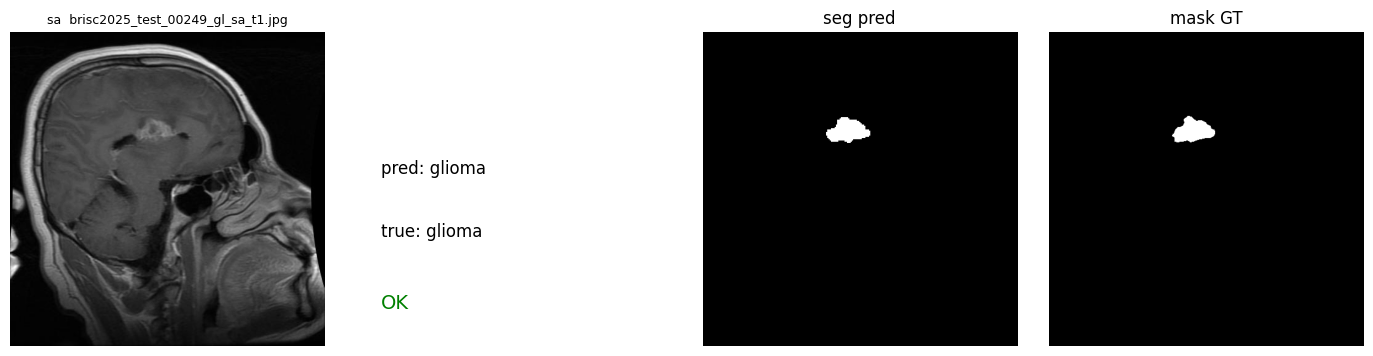

Класс: pred=glioma  true=glioma  OK


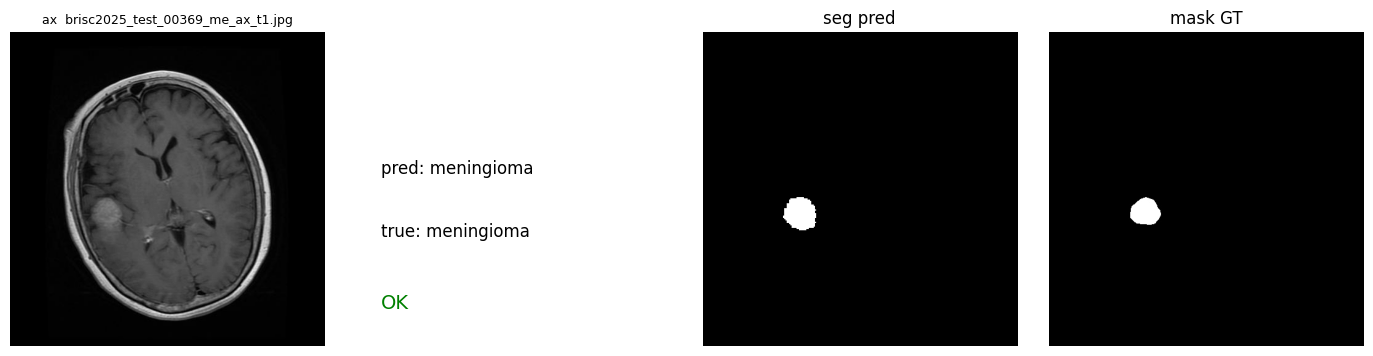

Класс: pred=meningioma  true=meningioma  OK


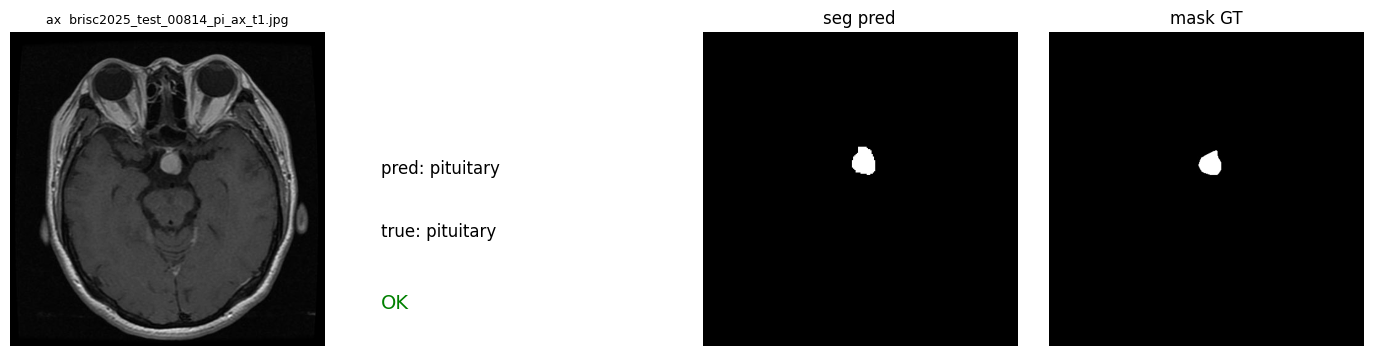

Класс: pred=pituitary  true=pituitary  OK


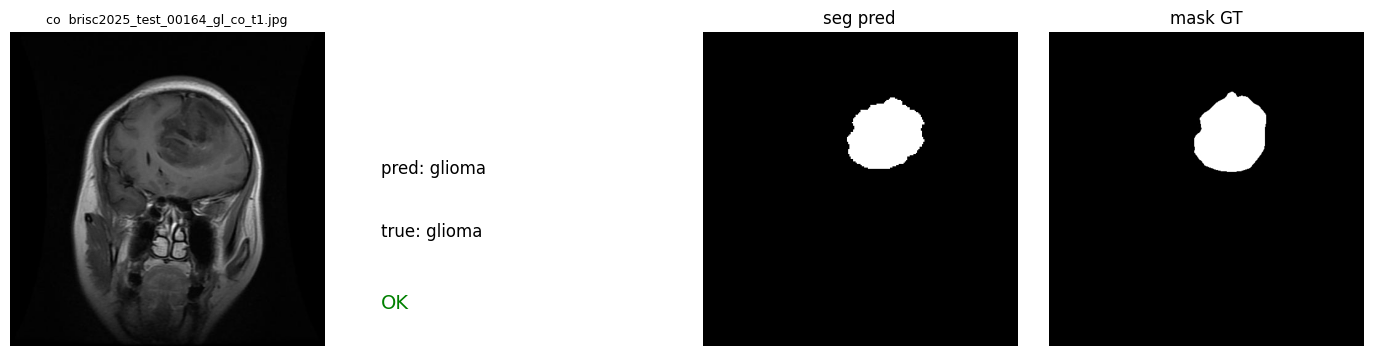

Класс: pred=glioma  true=glioma  OK


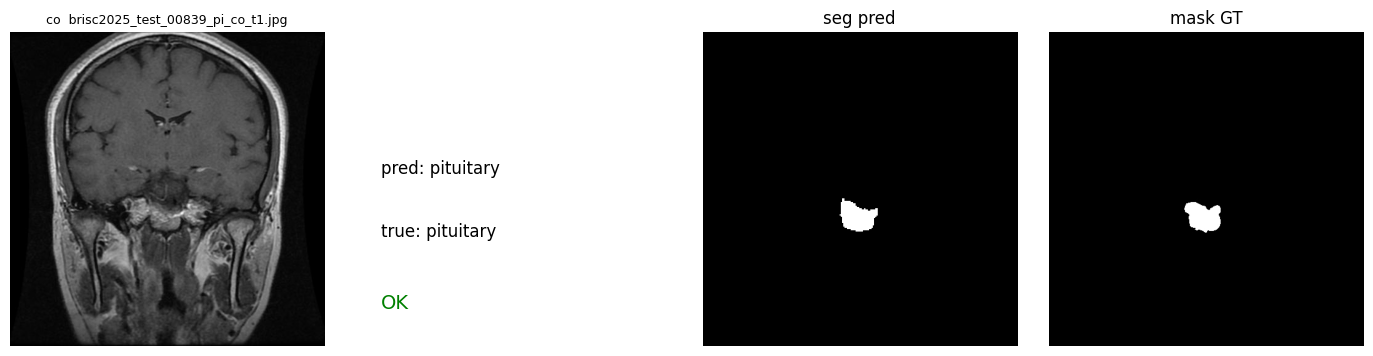

Класс: pred=pituitary  true=pituitary  OK


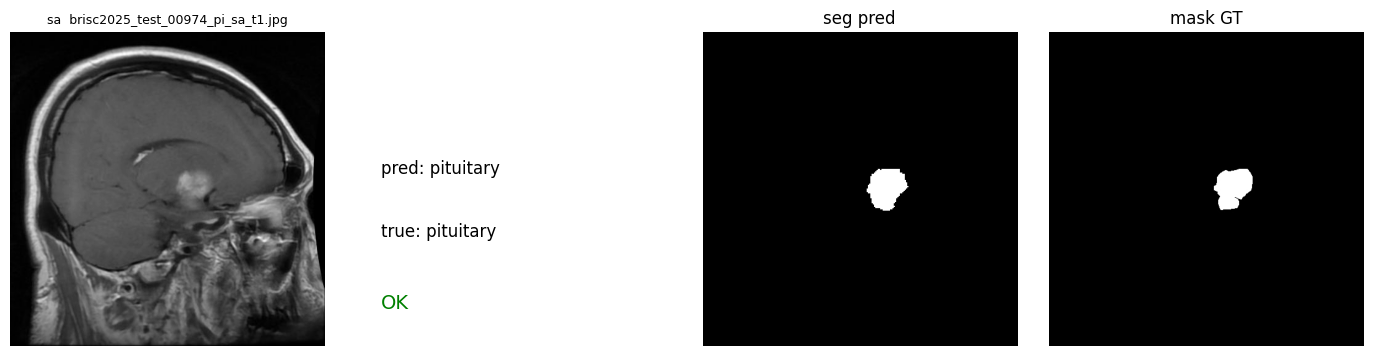

Класс: pred=pituitary  true=pituitary  OK


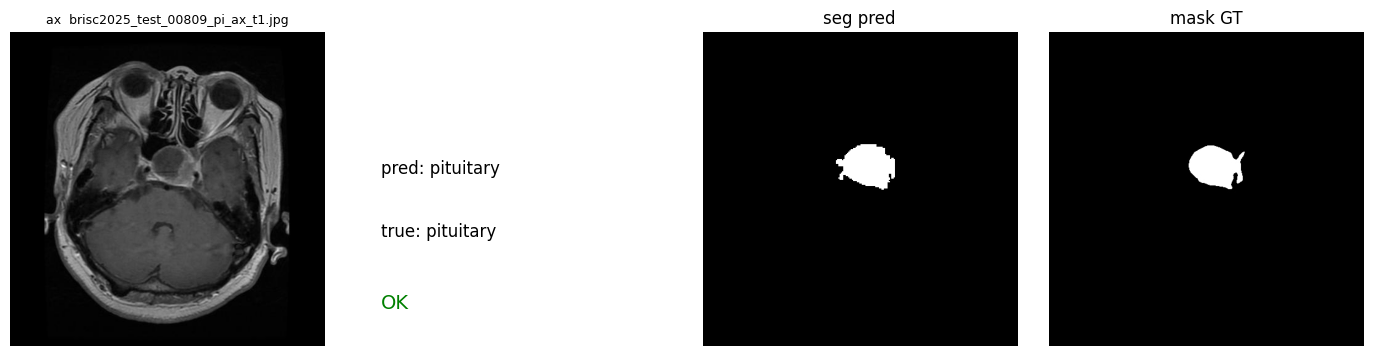

Класс: pred=pituitary  true=pituitary  OK


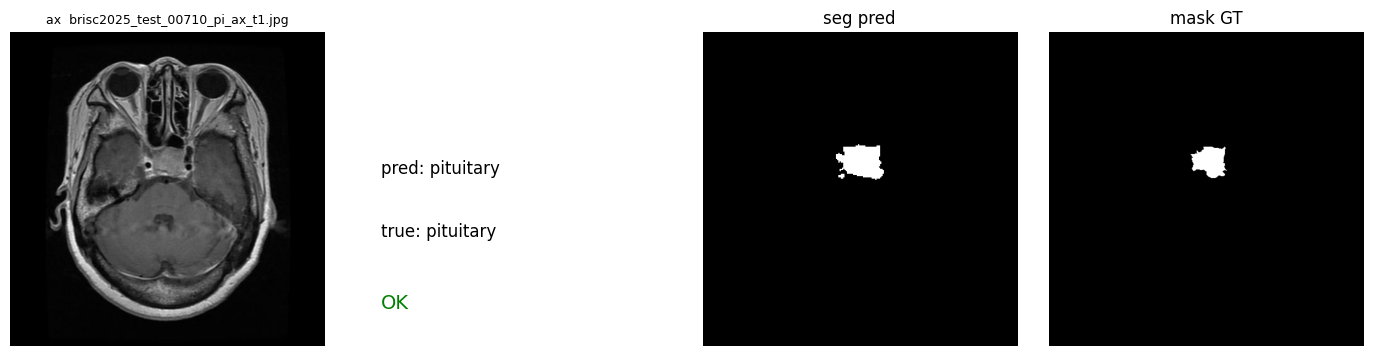

Класс: pred=pituitary  true=pituitary  OK


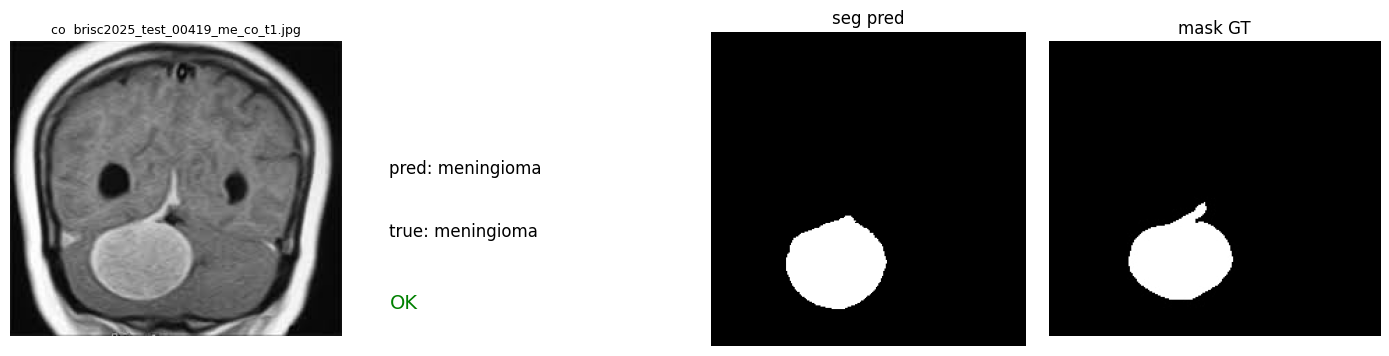

Класс: pred=meningioma  true=meningioma  OK


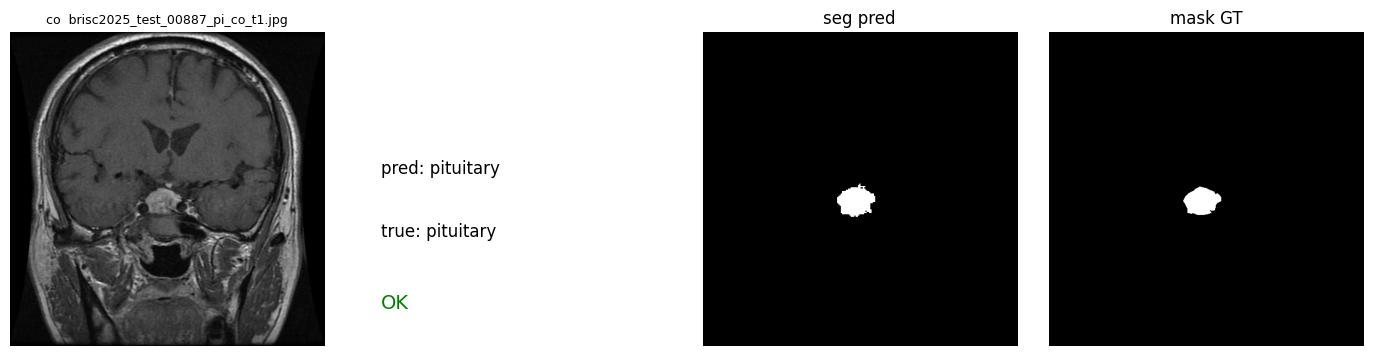

Класс: pred=pituitary  true=pituitary  OK


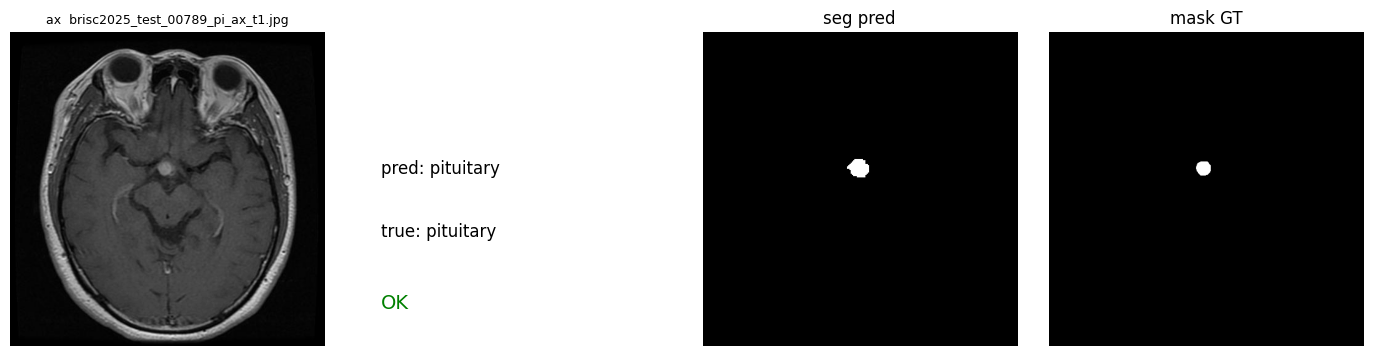

Класс: pred=pituitary  true=pituitary  OK


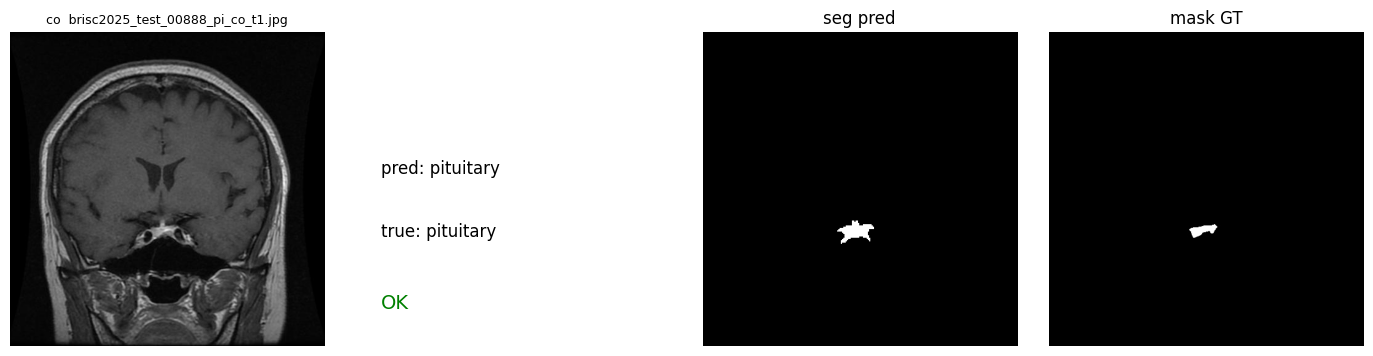

Класс: pred=pituitary  true=pituitary  OK


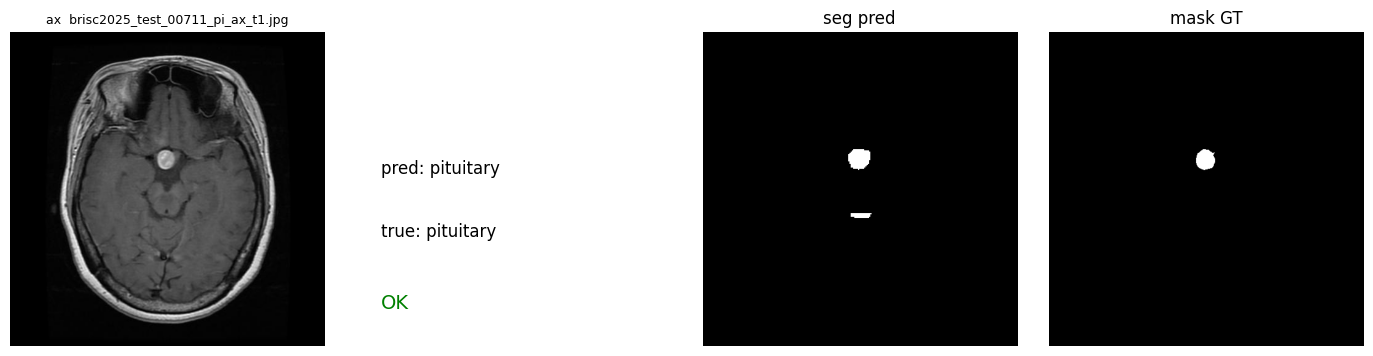

Класс: pred=pituitary  true=pituitary  OK


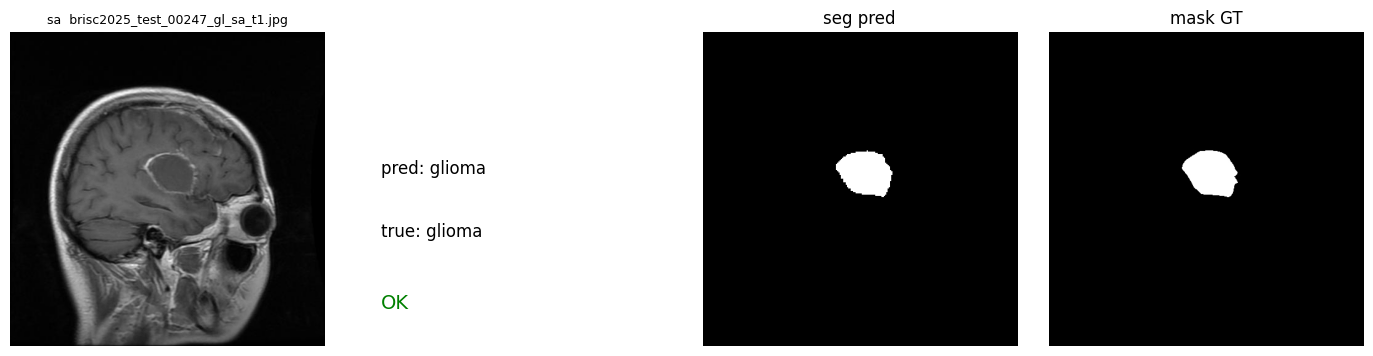

Класс: pred=glioma  true=glioma  OK


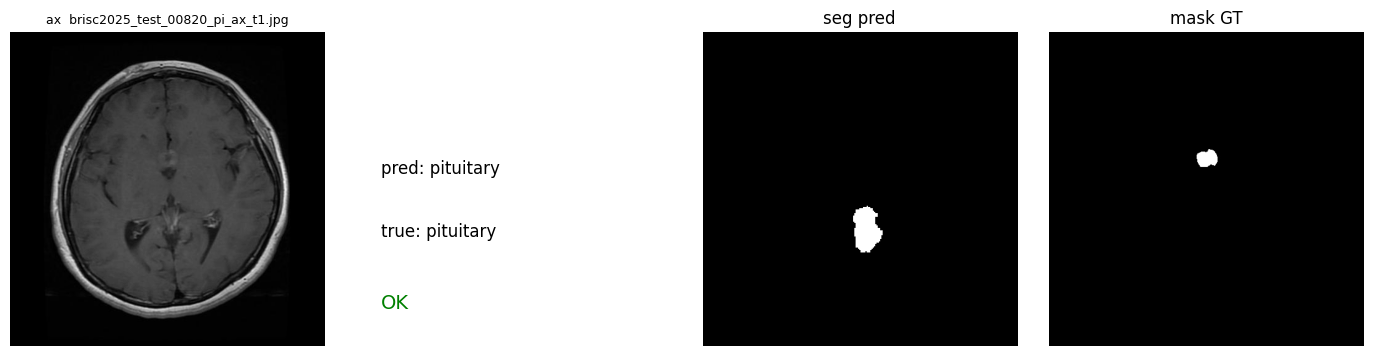

Класс: pred=pituitary  true=pituitary  OK


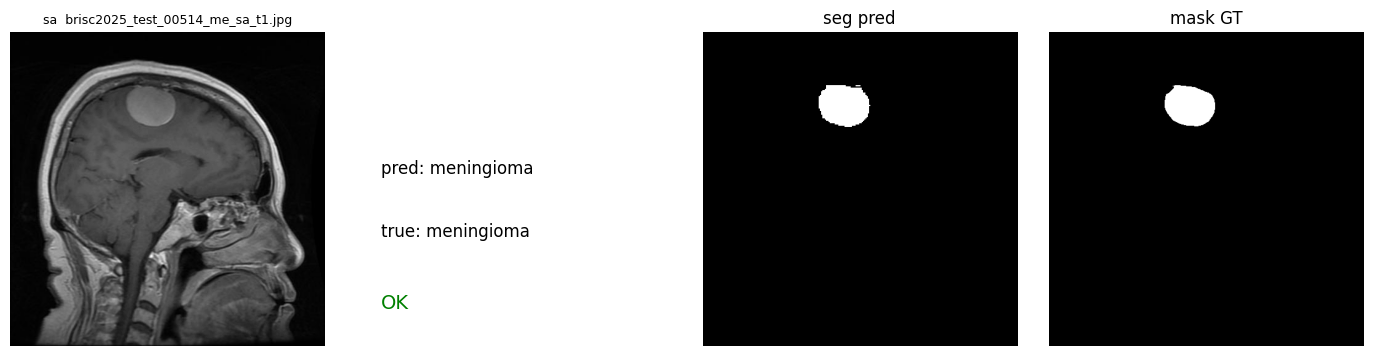

Класс: pred=meningioma  true=meningioma  OK


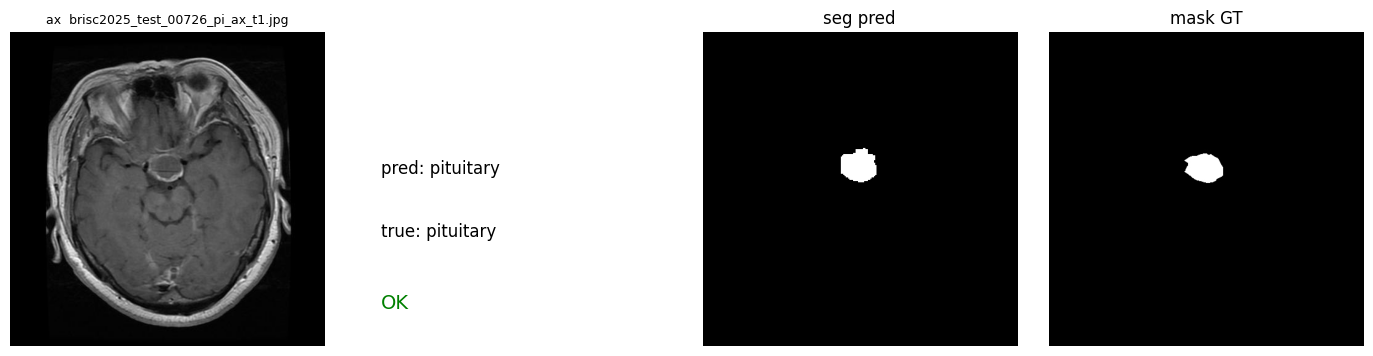

Класс: pred=pituitary  true=pituitary  OK


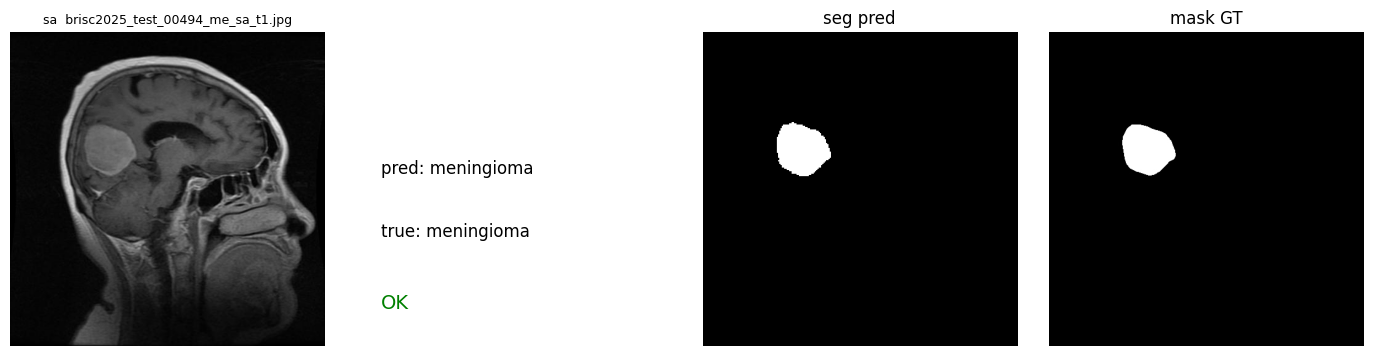

Класс: pred=meningioma  true=meningioma  OK


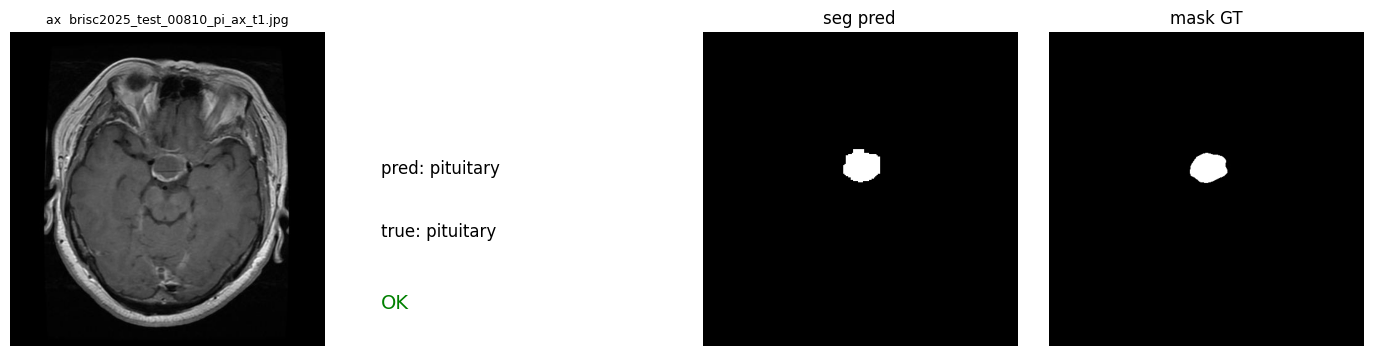

Класс: pred=pituitary  true=pituitary  OK


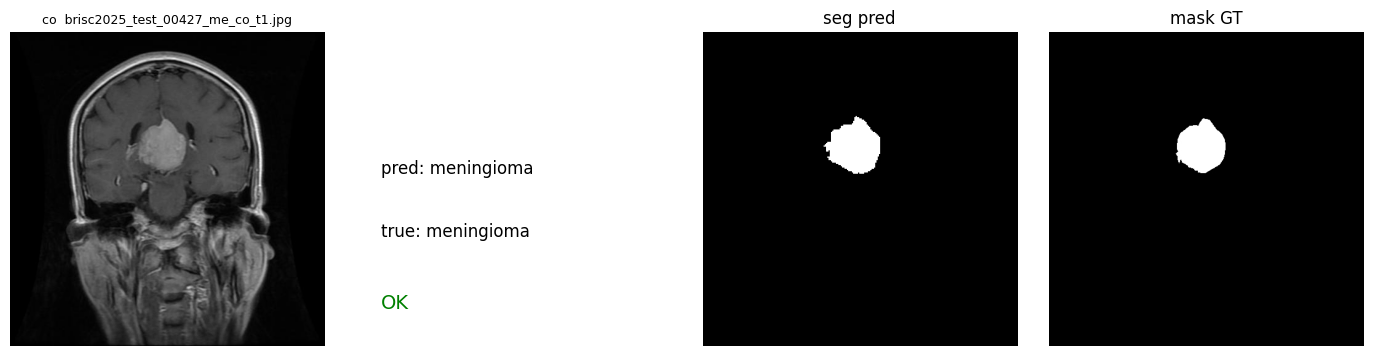

Класс: pred=meningioma  true=meningioma  OK


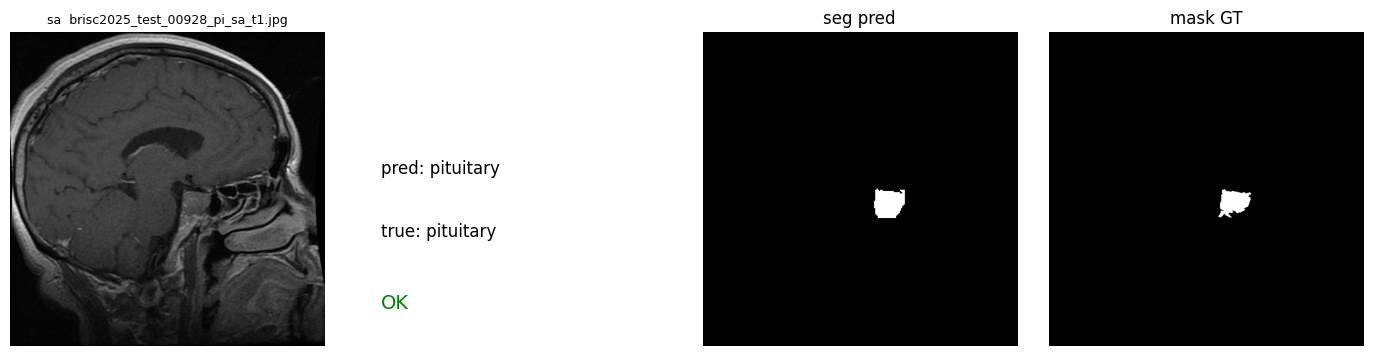

Класс: pred=pituitary  true=pituitary  OK


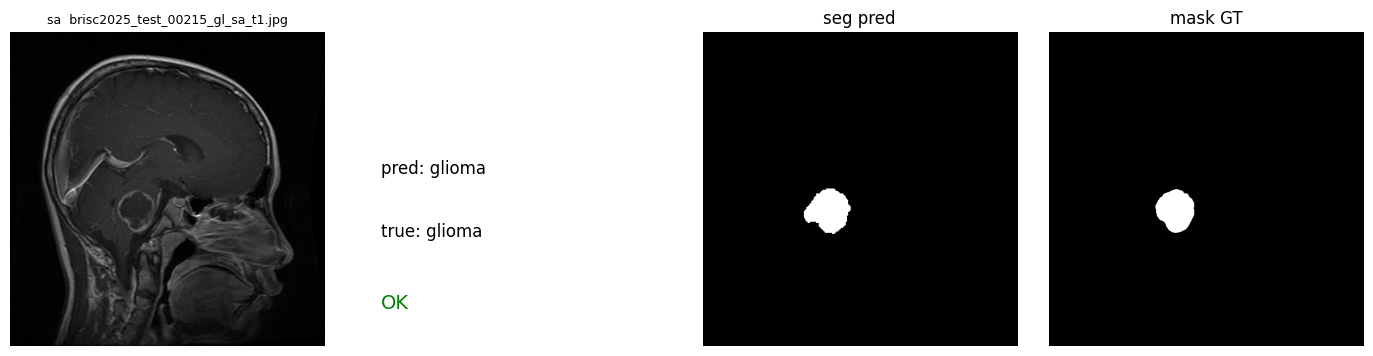

Класс: pred=glioma  true=glioma  OK


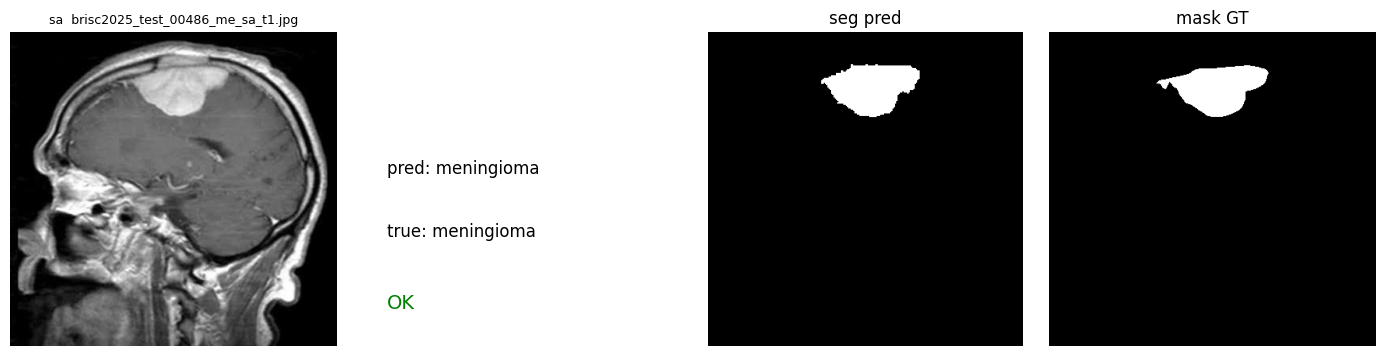

Класс: pred=meningioma  true=meningioma  OK


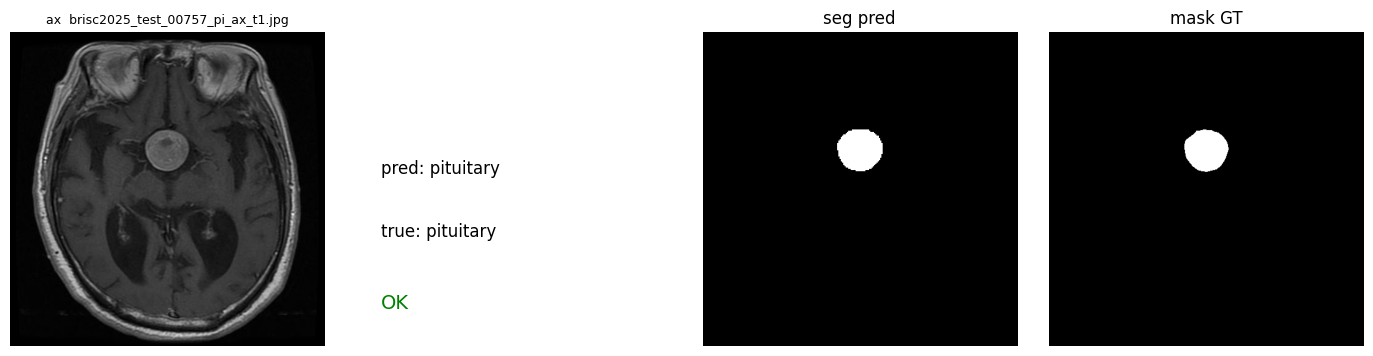

Класс: pred=pituitary  true=pituitary  OK


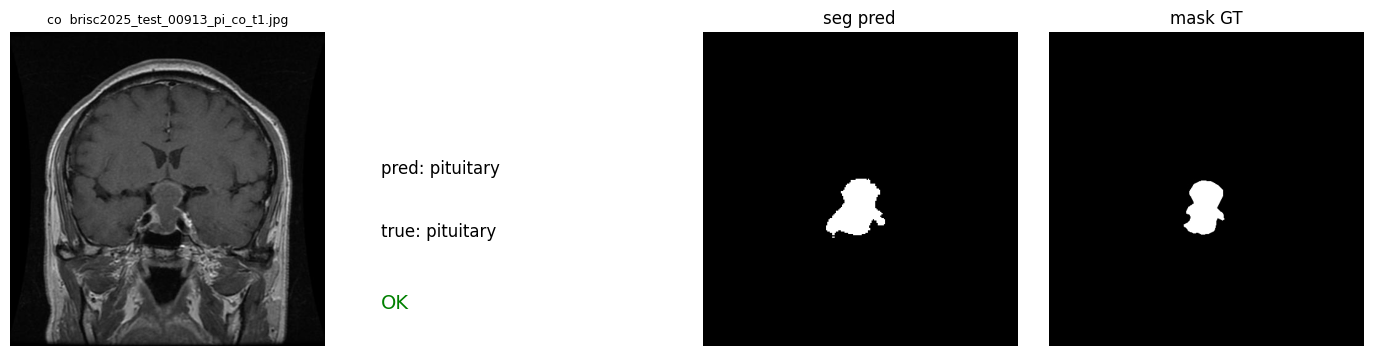

Класс: pred=pituitary  true=pituitary  OK


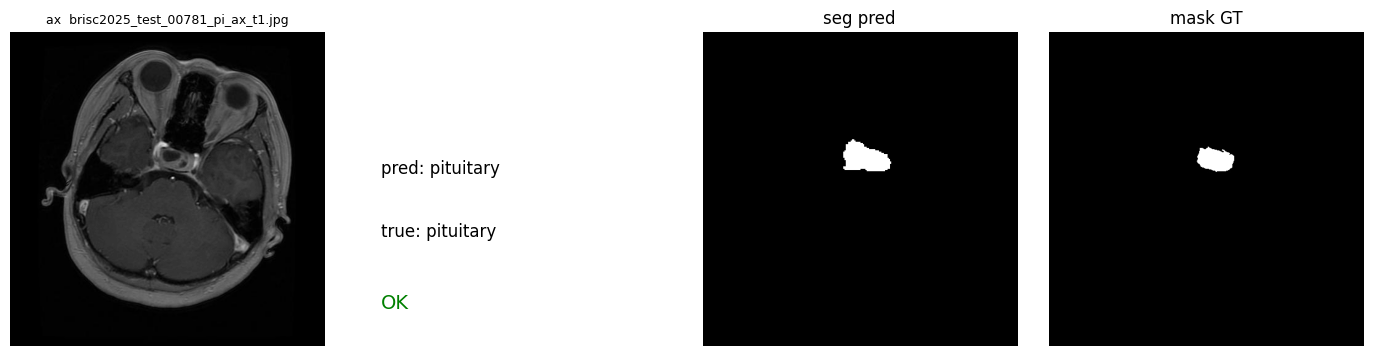

Класс: pred=pituitary  true=pituitary  OK


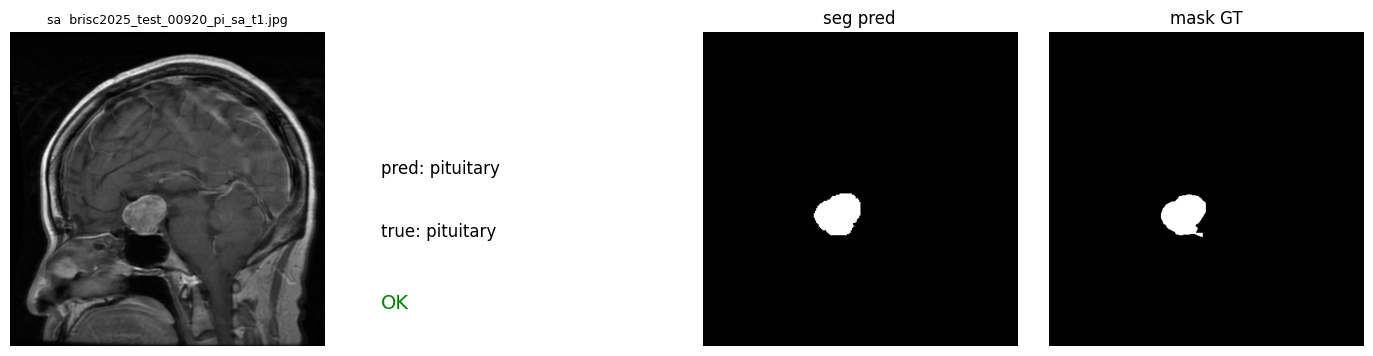

Класс: pred=pituitary  true=pituitary  OK


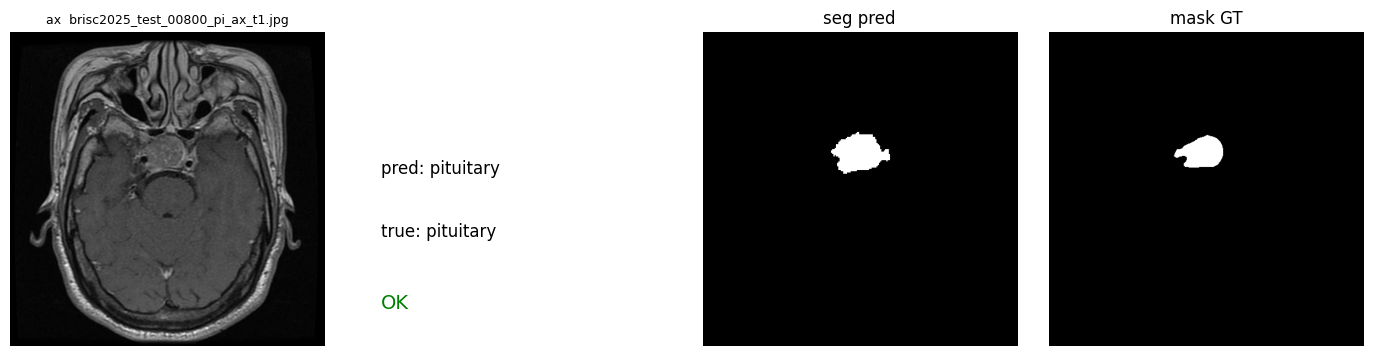

Класс: pred=pituitary  true=pituitary  OK


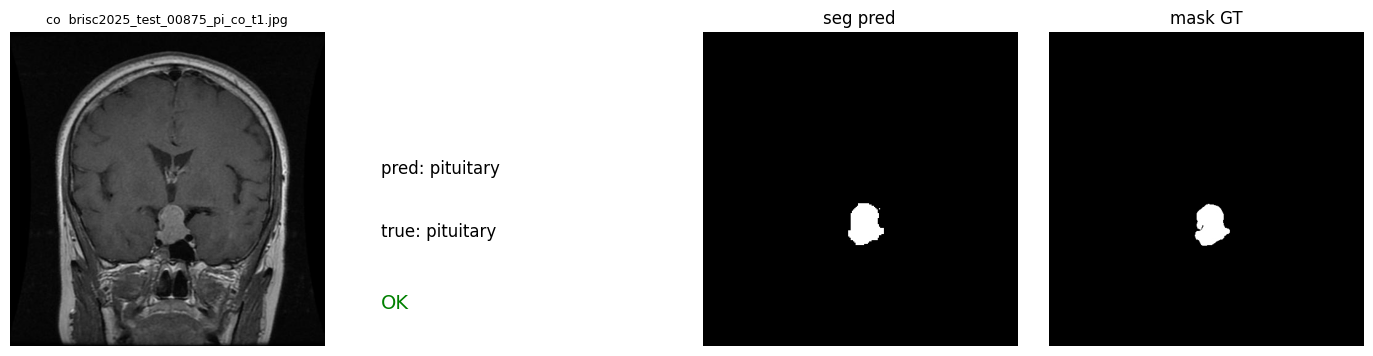

Класс: pred=pituitary  true=pituitary  OK


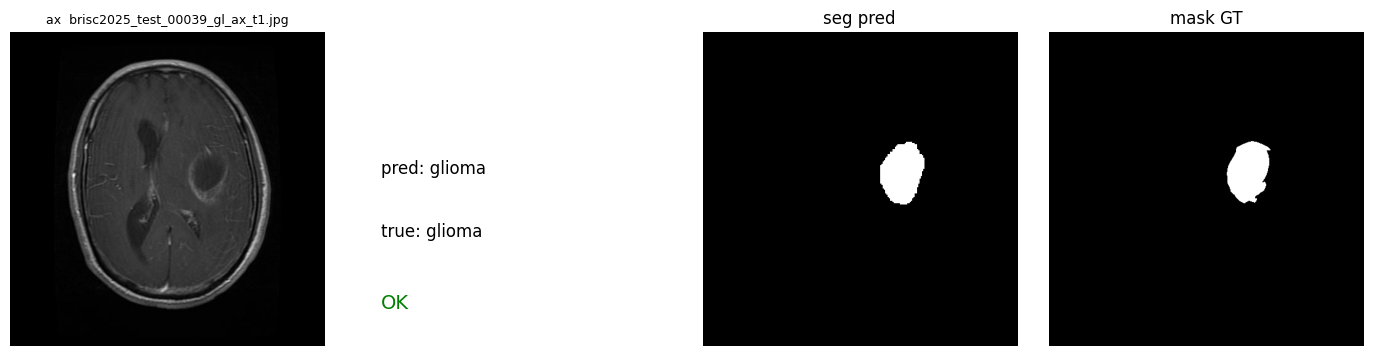

Класс: pred=glioma  true=glioma  OK


In [10]:
import random
N = 30

candidates: list[Path] = []
for pl in ("ax", "co", "sa"):
    img_dir = DATA_SEG / pl / "test" / "images"
    if not img_dir.is_dir():
        continue
    for p in img_dir.glob("*.jpg"):
        mask = p.parent.parent / "masks" / f"{p.stem}.png"
        if mask.is_file():
            candidates.append(p.resolve())

if not candidates:
    raise FileNotFoundError(f"Нет пар изображение+маска под {DATA_SEG.resolve()}")

k = min(N, len(candidates))
chosen = random.sample(candidates, k)
print(f"Выбрано {k} из {len(candidates)} тестовых снимков")

for path in chosen:
    plane = path.parent.parent.parent.name
    show_prediction(path, plane)


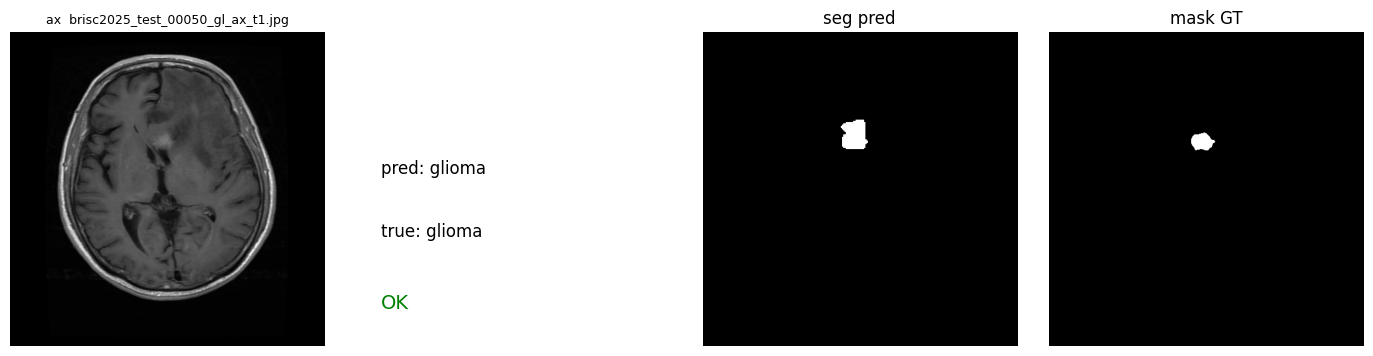

Класс: pred=glioma  true=glioma  OK


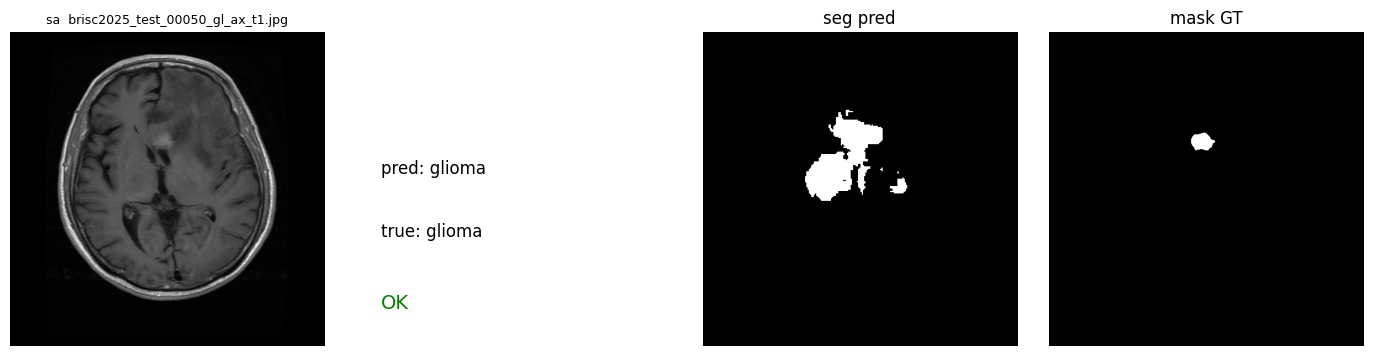

Класс: pred=glioma  true=glioma  OK


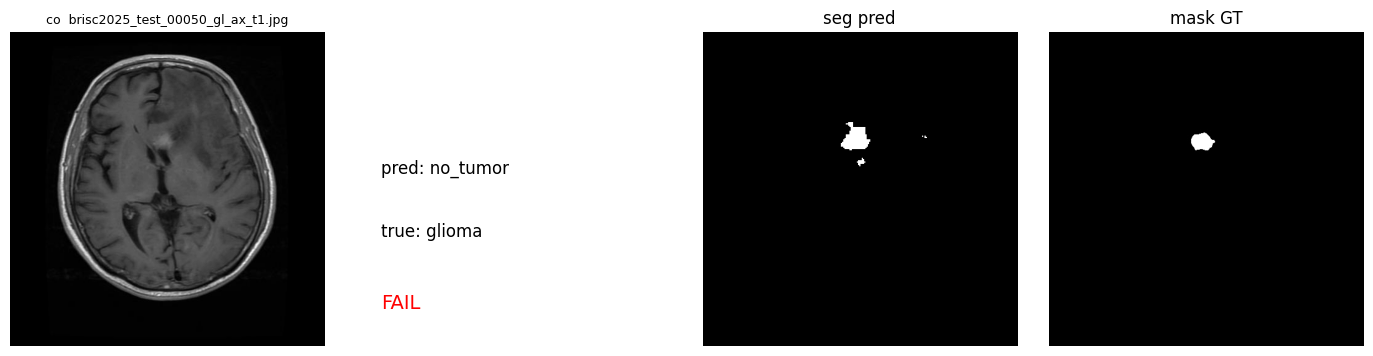

Класс: pred=no_tumor  true=glioma  FAIL


In [11]:
_example = DATA_SEG / "ax" / "test" / "images" / "brisc2025_test_00050_gl_ax_t1.jpg"
show_prediction(_example, "ax")
show_prediction(_example, "sa")
show_prediction(_example, "co")